# Value at Risk and Conditional Value at Risk.
This notebook will demonstrate how Value at Risk (VaR) and Conditional Value at Risk (CVaR) can be calculated in this repository.

Note: To avoid fetching data from yfinance every time DataIngestion is called, as mentioned previously, save the files from DataIngestion as a a file of your choice, or cache the files in memory. This will speed up the processing of the data and allow you to quickly calculate VaR, CVaR, and other Financial Mathematical calculations in this project.

## Illustration of Returns.
Before the calculating VaR and CVaR, here is an illustration of returns as a histogram with all asset classes in this dataset.

[*********************100%***********************]  120 of 120 completed
/tmp/ipykernel_36922/323067183.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Assets", bbox_to_anchor=(1.02, 1), loc="upper left")


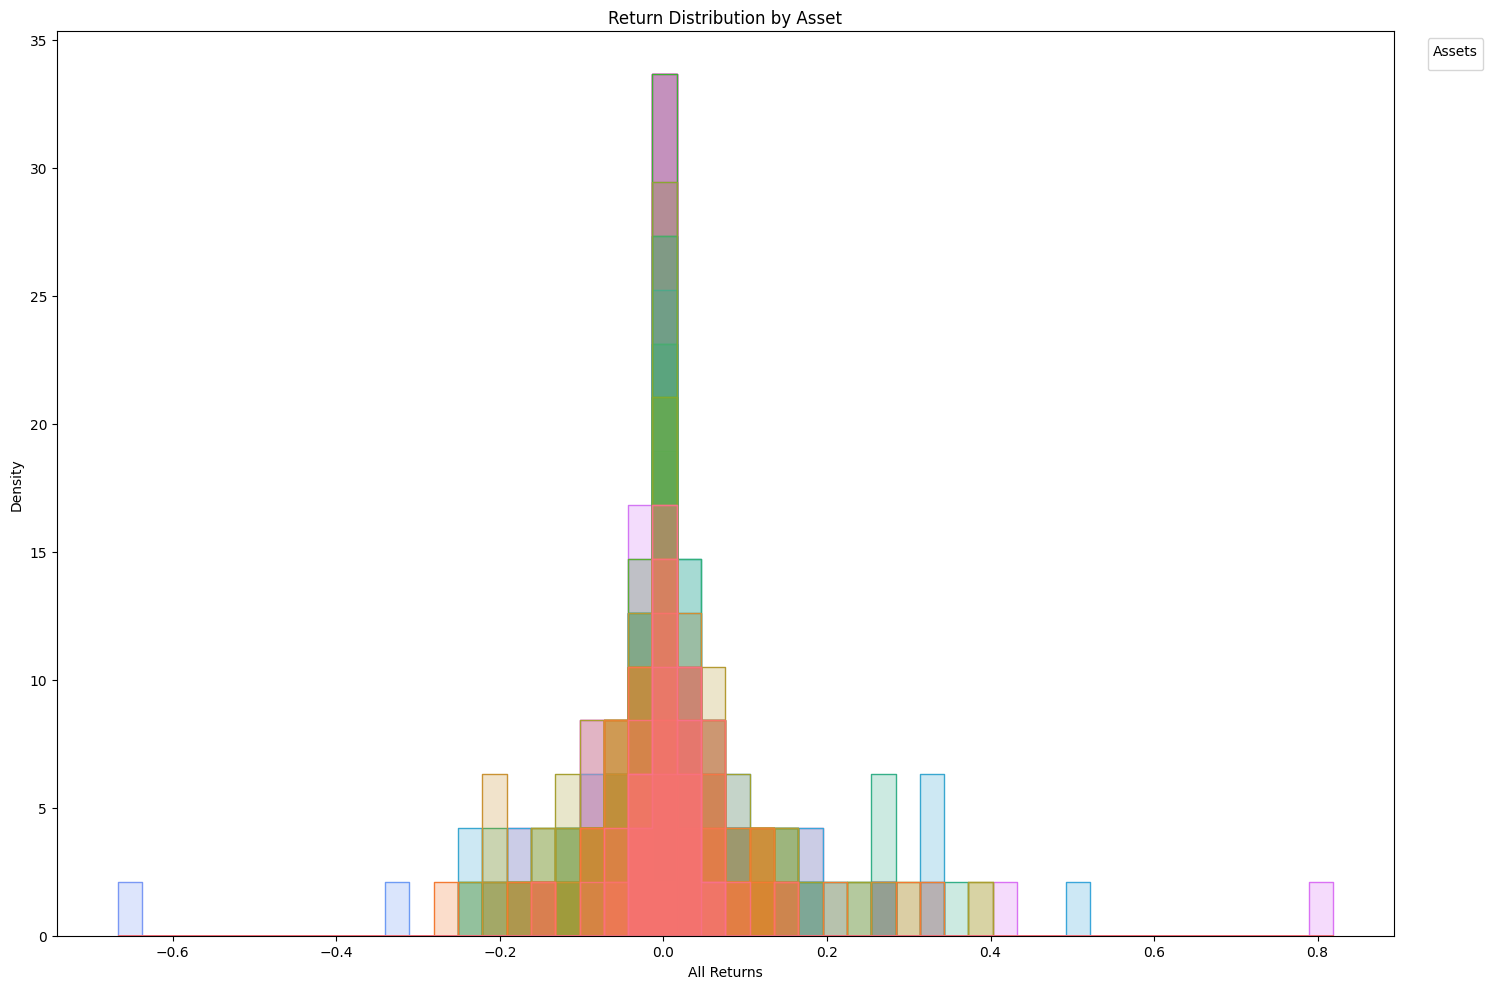

In [1]:
# data ingestion
import matplotlib.pyplot as plt
import seaborn as sns

from portfolio.data.data_ingestion import DataIngestion


obj = DataIngestion()

# all prices for all returns

all_prices = obj.get_all_prices()


# all returns using 'get_all_prices' method.

all_returns = obj.compute_returns(all_prices)


# all_returns: DataFrame with one column per asset
returns_long = all_returns.stack().reset_index()
returns_long.columns = ["Date", "Asset", "Return"]

plt.figure(figsize=(15, 10))
sns.histplot(
    data=returns_long,
    x="Return",
    hue="Asset",
    bins=50,
    element="step",
    stat="density",
    common_norm=False,
    alpha=0.25,
)

plt.xlabel("All Returns")
plt.ylabel("Density")
plt.title("Return Distribution by Asset")
plt.legend(title="Assets", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Explanation of the output
The histogram shows the distribution of all returns in the dataset, this includes all stocks, all bonds, all etf's, all crypto currencies, and the SP500 ticker. The point of this is this is to demonstrate the distribution of a high number of assets returns. This is the Central Limit Theorem. As more samples are added to the distribution, the distribution will approach a normal distribution. This is important to understand when calculating VaR and CVaR, as these calculations assume that returns are normally distributed.

## Returns with less assets.
The next histogram will demonstrate what the distribution of returns looks like when there are less samples.

[*********************100%***********************]  4 of 4 completed


<Figure size 1500x1000 with 0 Axes>

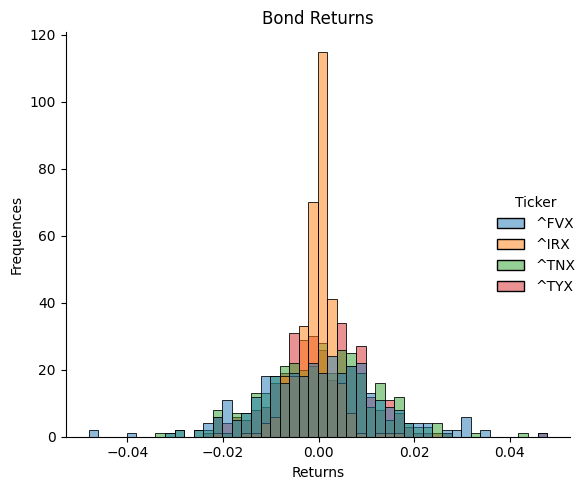

In [2]:
# returns of bonds.

bond_returns = obj.compute_returns(obj.get_bond_prices())

plt.figure(figsize=(15, 10))
sns.displot(bond_returns)
plt.title("Bond Returns")
plt.xlabel("Returns")
plt.ylabel("Frequences")
plt.tight_layout()
plt.show()

### Explanation of the output
The histogram is still close to resembling a bell curve, however, it is slightly skewed to the left. Bonds are safe assets and usually, the risk-free rate is the default risk on a t-bill. A very safe asset. Most of the returns in this histogram lie in the middle of the bell curve.Yet,  due to a lack of samples, this is not demonstrating the central limit theorem, unlike the histogram with all returns.

## Crypto Returns.
The next histogram will demonstrate what the distribution of returns looks like when there are only crypto assets.

[*********************100%***********************]  26 of 26 completed


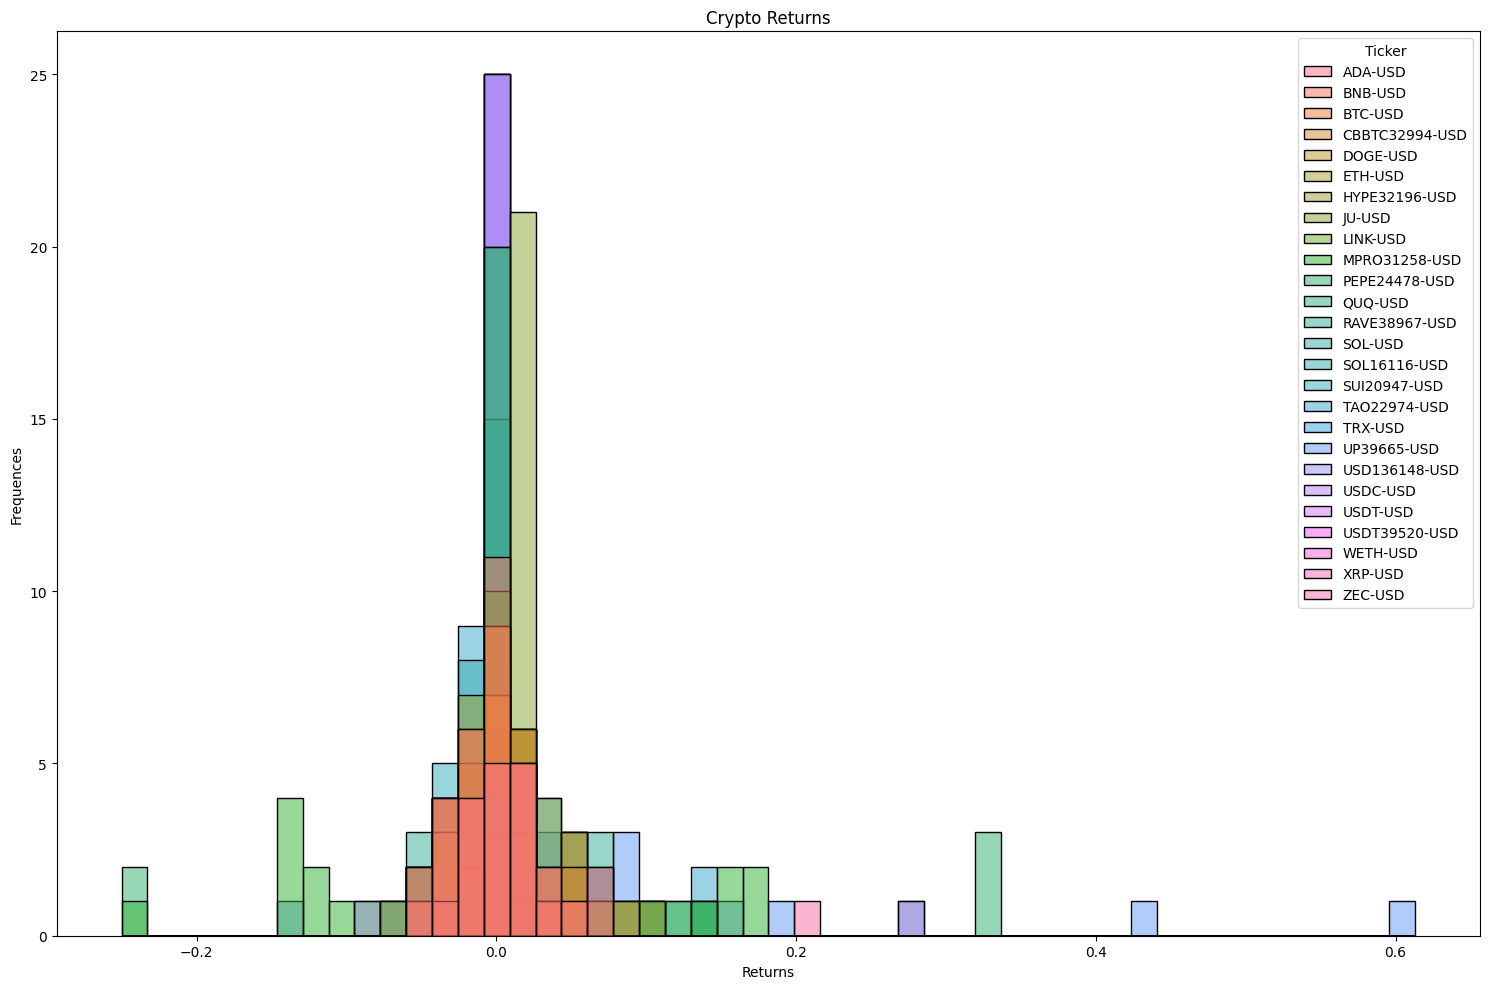

In [3]:
crypto_returns = obj.compute_returns(obj.get_crypto_prices())

plt.figure(figsize=(15, 10))
sns.histplot(crypto_returns, bins=50)
plt.title("Crypto Returns")
plt.xlabel("Returns")
plt.ylabel("Frequences")
plt.tight_layout()
plt.show()

### Explanation of the output
This histogram is skewed to the right (a little). When assets are skewed to the right, this means there are more positive returns than negative returns. Is this good? Does a distribution of positive returns mean that the asset is a good investment? No. Say you see that the returns for some crypto currency is skewed to the right. This means more people will buy the ones to the right, more than likely causing the value to come back to the middle because the number of returns is not normally distributed. 

For a long time, crypto currencies were not regulated. There were no financial intermediaries, no government regulation, ect. Most assets like bonds, stocks, etfs, gold, silver, and other commodities are regulated or issued by a central bank of that country. For a long time, this was not the case with crypto currencies. This would make returns on crypto currencies very unpredictable.

When some form of money is not regulated is this good? To answer that, one must ask: What makes a object money?
Money can be defined as any sort of thing have these three properties: 1. Store of Value, 2.Medium of Exchange. 3. Unit of Account. A store of value is say, you have gold, people want gold, you store it. A medium of exchange is something tangible that can be used to trade for goods and services. This is important. If money was not a medium of exchange, everyone would have to lie on a double coincidence of wants to survive. Say you sell jackets and someone else sells haircuts. What if you wanted a haircut, but you could only sell jackets and the person giving haircuts does not want a jacket? This would be so inconvenient. So, money comes into play to break this extremely inconvenient system and has since the dawn of man.  A unit of account is a standard numerical unit of measurement of the market value of goods, services, and other transactions. This is important because it allows us to compare the value of different goods and services.

Cigarettes and snacks inside of prisons are literally money. But outside that prison, is it money? No. Does everyone in the world accept Crypto Currencies as a medium of exchange? No. Do most people accept some currency as money? Yes. If money is tied to something in high demand and is scare, do people want it? Usually. Is crypto tied to anything in high demand that has worth backing it. No. Does Nvidia have worth behind the stock? Some tangible thing that people want and is rare? Yes. 

## Value at Risk (VaR)
The Value at Risk (VaR) is a measure of the potential loss in value of a portfolio over a defined period for a given confidence interval.

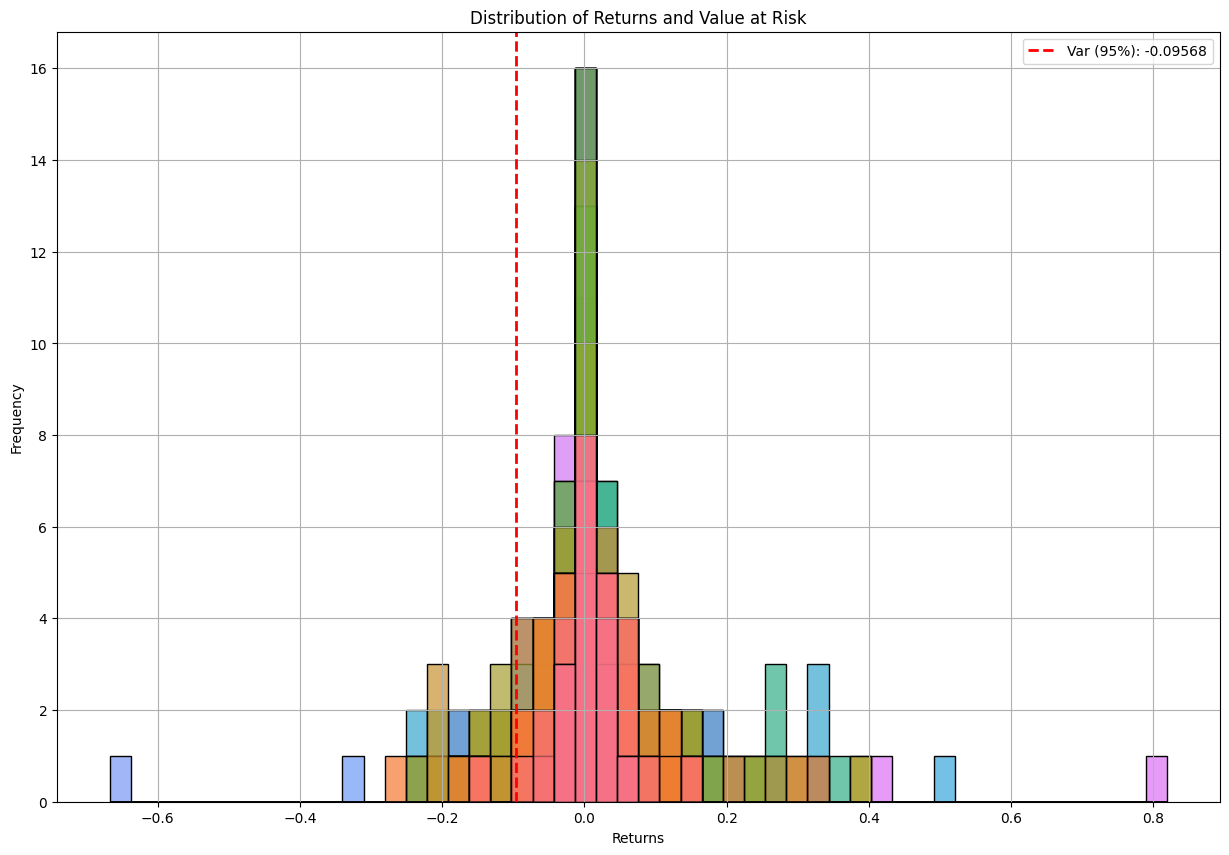

In [4]:
from portfolio.models.risk import get_var

# value at risk for all prices
var_all = get_var(all_prices)


plt.figure(figsize=(15, 10))
sns.histplot(all_returns, bins=50, alpha=0.7)
plt.axvline(var_all, color='r', linestyle='dashed', linewidth=2, label=f'Var (95%): {var_all:.4}')
plt.title('Distribution of Returns and Value at Risk')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

## Conditional Value at Risk (CVaR)
The Conditional Value at Risk (CVaR) is a measure of the expected loss in value of a portfolio over a defined period for a given confidence interval, given that the loss exceeds the VaR. It is also known as the Expected Shortfall (ES). The Conditional Value at Risk is usually viewed as the worst case scenario of the Value at Risk. It is the expected loss given that the loss exceeds the VaR. It is a more conservative measure of risk than VaR, as it takes into account the tail risk of the distribution of returns.


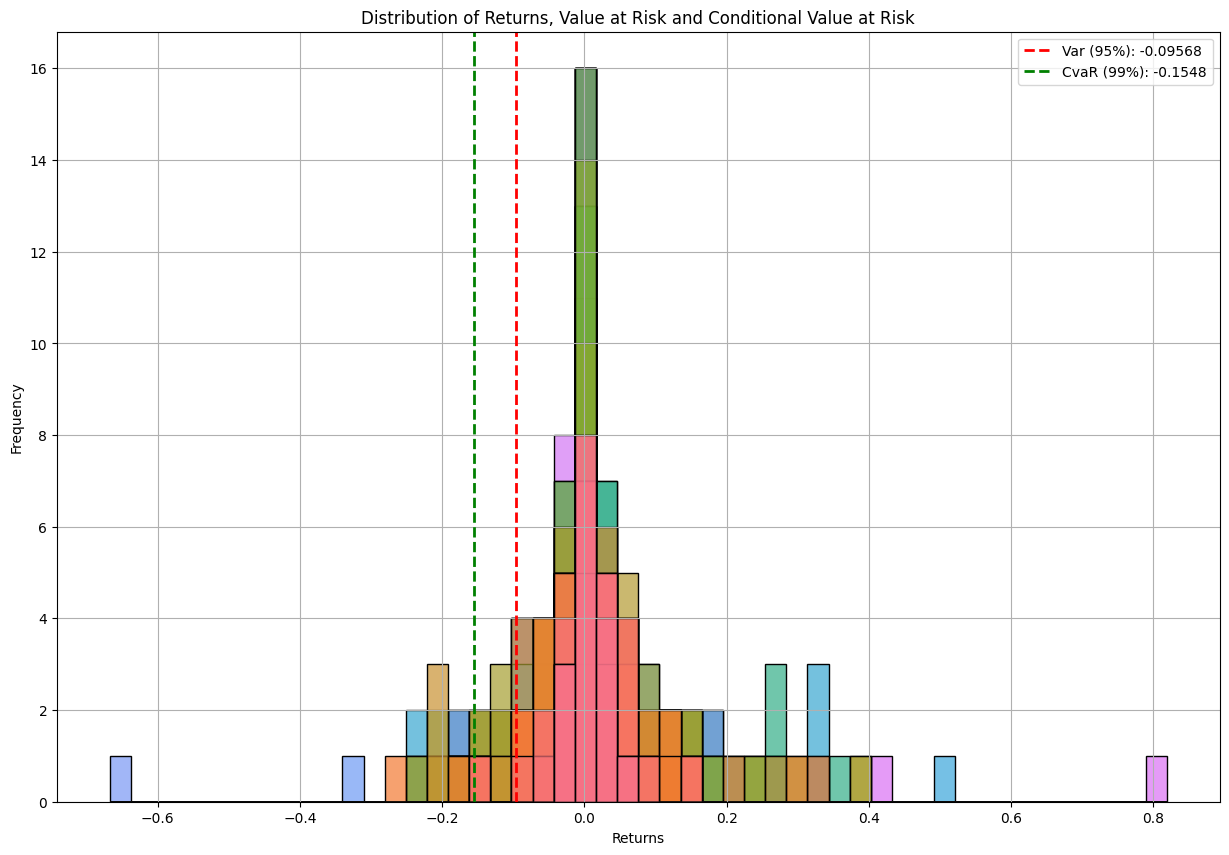

In [5]:
from portfolio.models.risk import get_cvar

cvar_all = get_cvar(all_prices)

plt.figure(figsize=(15, 10))
sns.histplot(all_returns, bins=50, alpha=0.7)
plt.axvline(var_all, color='r', linestyle='dashed', linewidth=2, label=f'Var (95%): {var_all:.4}')
plt.axvline(cvar_all, color='g', linestyle='dashed', linewidth=2, label=f'CvaR (99%): {cvar_all:.4}')
plt.title('Distribution of Returns, Value at Risk and Conditional Value at Risk')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()





### Explanation of the output
The histogram shows both the Value at Risk and the Conditional Value at Risk as a vertical line. As is shown, the Conditional Value at Risk is further to the left than the Value at Risk.

## VaR and CVar with other asset classes.
The Value at Risk and Conditional Value at Risk can be used on other asset classes as well. Here is an example of the Value at Risk and Conditional Value at Risk for the only stock returns.

[*********************100%***********************]  54 of 54 completed


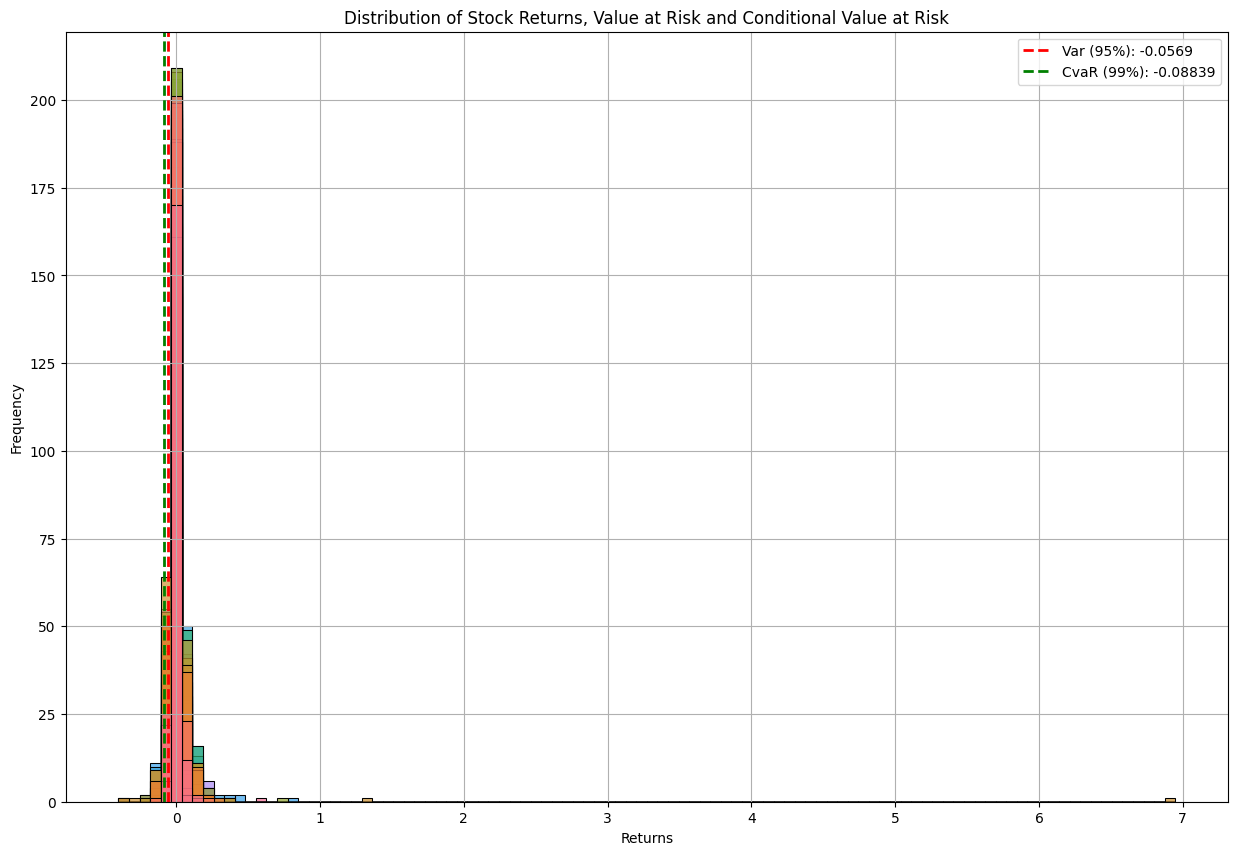

In [6]:
# load in stock prices and computer stock returns.
stock_prices = obj.get_stock_prices()
stock_returns = obj.compute_returns(stock_prices)


# Value at Risk and Conditional Value at Risk for stocks.
var_stocks = get_var(stock_prices)
cvar_stocks = get_cvar(stock_prices)




plt.figure(figsize=(15, 10))
sns.histplot(stock_returns, bins=100, alpha=0.7)
plt.axvline(var_stocks, color='r', linestyle='dashed', linewidth=2, label=f'Var (95%): {var_stocks:.4}')
plt.axvline(cvar_stocks, color='g', linestyle='dashed', linewidth=2, label=f'CvaR (99%): {cvar_stocks:.4}')
plt.title('Distribution of Stock Returns, Value at Risk and Conditional Value at Risk')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()










[*********************100%***********************]  4 of 4 completed


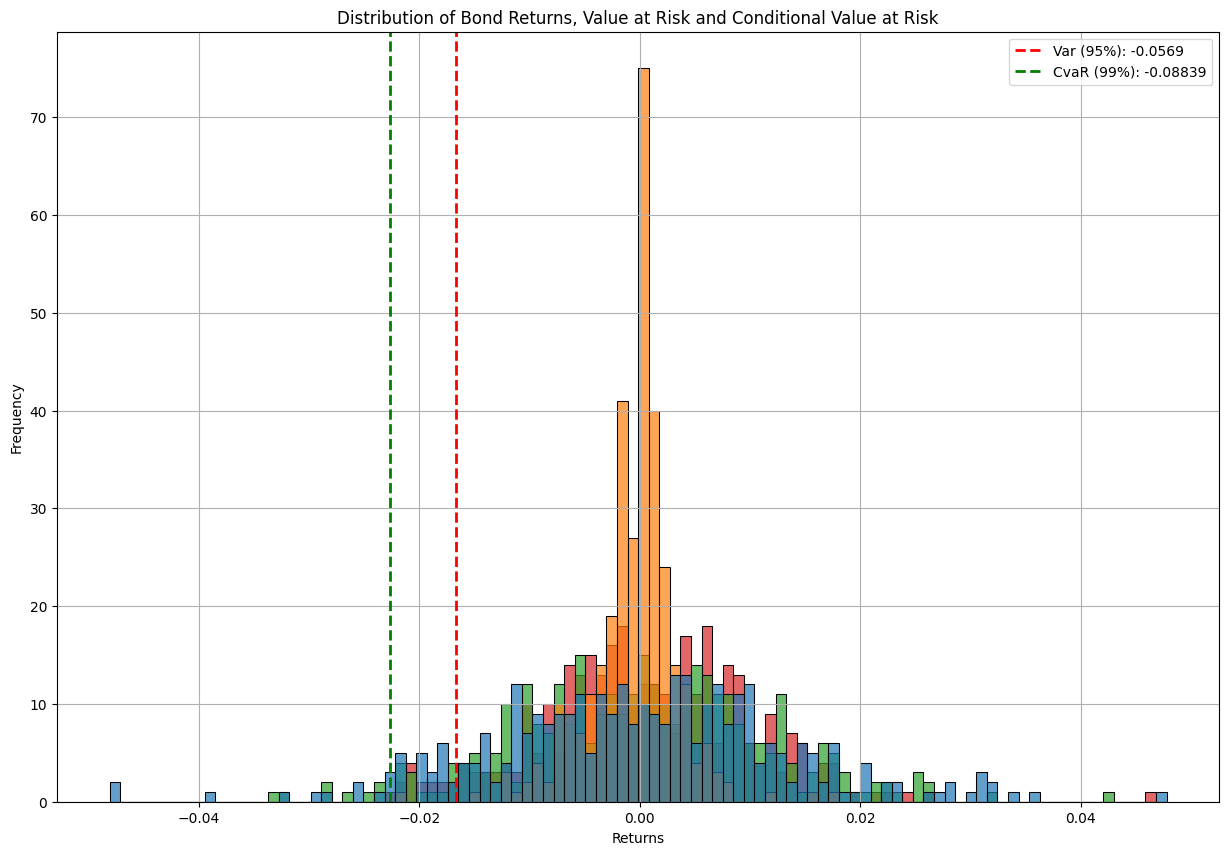

In [7]:
# bond VaR and CVaR

bond_prices = obj.get_bond_prices()
bond_returns = obj.compute_returns(bond_prices)

# VaR and CVaR for bonds.
var_bonds = get_var(bond_prices)
cvar_bonds = get_cvar(bond_prices)


plt.figure(figsize=(15, 10))
sns.histplot(bond_returns, bins=100, alpha=0.7)
plt.axvline(var_bonds, color='r', linestyle='dashed', linewidth=2, label=f'Var (95%): {var_stocks:.4}')
plt.axvline(cvar_bonds, color='g', linestyle='dashed', linewidth=2, label=f'CvaR (99%): {cvar_stocks:.4}')
plt.title('Distribution of Bond Returns, Value at Risk and Conditional Value at Risk')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()



[*********************100%***********************]  36 of 36 completed


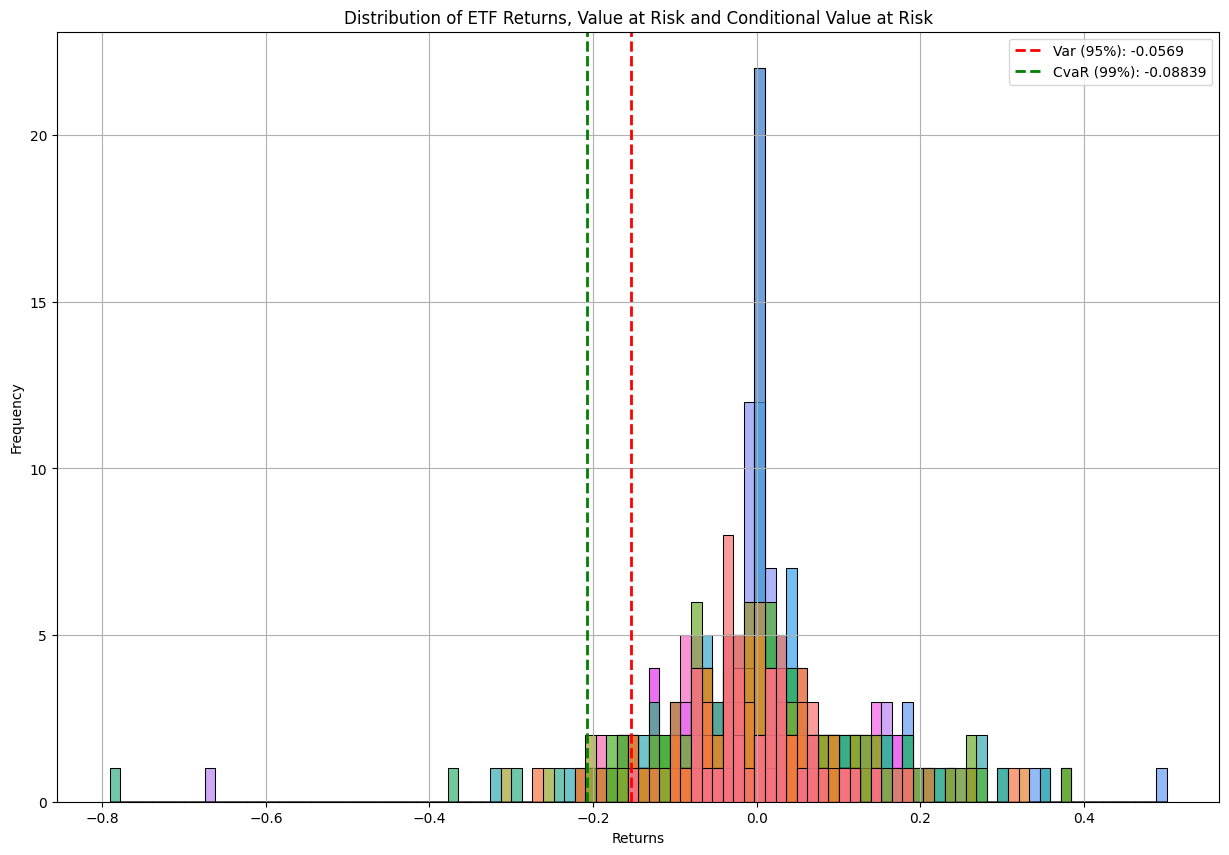

In [8]:
# Etf VaR and CVaR

etf_prices = obj.get_etf_prices()
etf_returns = obj.compute_returns(etf_prices)

var_etf = get_var(etf_prices)
cvar_etf = get_cvar(etf_prices)


plt.figure(figsize=(15, 10))
sns.histplot(etf_returns, bins=100, alpha=0.7)
plt.axvline(var_etf, color='r', linestyle='dashed', linewidth=2, label=f'Var (95%): {var_stocks:.4}')
plt.axvline(cvar_etf, color='g', linestyle='dashed', linewidth=2, label=f'CvaR (99%): {cvar_stocks:.4}')
plt.title('Distribution of ETF Returns, Value at Risk and Conditional Value at Risk')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

